In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from clayton.rng import Gaussian
from pycop import simulation
from scipy.stats import norm

import pickle as pc
from pathlib import Path

plt.rcParams['text.usetex'] = True
rng = np.random.default_rng(12349053761341025)


In [61]:
def inverse_heavy_tail_cdf(sample, cutoff=1, tail_parameter=1/4): 
    return np.exp(np.log(cutoff) - np.log((1-sample))*tail_parameter)

class Sample():
    def __init__(self, samples):
        self.unif_samples = samples

class GaussianSample(Sample):
    def sample(self, scale) : 
        return norm.ppf(self.unif_samples, scale = scale)

class HeavyTailSample(Sample):
    def sample(self, cutoff, tail_parameter):
        return inverse_heavy_tail_cdf(self.unif_samples, cutoff=cutoff, tail_parameter=tail_parameter)

class Metric(Sample):
    def __init__(self, goal:Sample, noise:Sample):
        self.goal = goal
        self.noise = noise
        self.freeze = False
    
    def sample(self,goal_arg = {}, noise_arg = {}):
        return self.goal.sample(**goal_arg) + self.noise.sample(**noise_arg)
    
    def freeze_sample(self, goal_arg = {}, noise_arg = {}):
        self.frozen_goal = self.goal.sample(**goal_arg)
        self.frozen_noise = self.noise.sample(**noise_arg)
        self.frozen_metric = self.frozen_goal + self.frozen_noise
        self.freeze = True

    def conditionnal_goal(self, metric_value): 
        if self.freeze : 
            mask  = self.frozen_metric >= metric_value
            return np.mean(self.frozen_goal[mask])

        else :
            raise RuntimeError("Samples must be frozen with freeze_sample methode first before computing conditionnal expectation")
        
    def conditionnal_correlation(self, metric_value): 
        if self.freeze : 
            mask  = self.frozen_metric >= metric_value
            mask_total = np.sum(mask)
            return np.corrcoef(self.frozen_goal[mask].reshape(1,mask_total), self.frozen_metric[mask].reshape(1,mask_total))

        else :
            raise RuntimeError("Samples must be frozen with freeze_sample methode first before computing conditionnal expectation")
        

In this, we are making experiment to assess the importance of copula in Goodhart's law prevalence.

# Gaussian tail :


### Clayton Copula : 

In [32]:
from clayton.rng.archimedean import Clayton

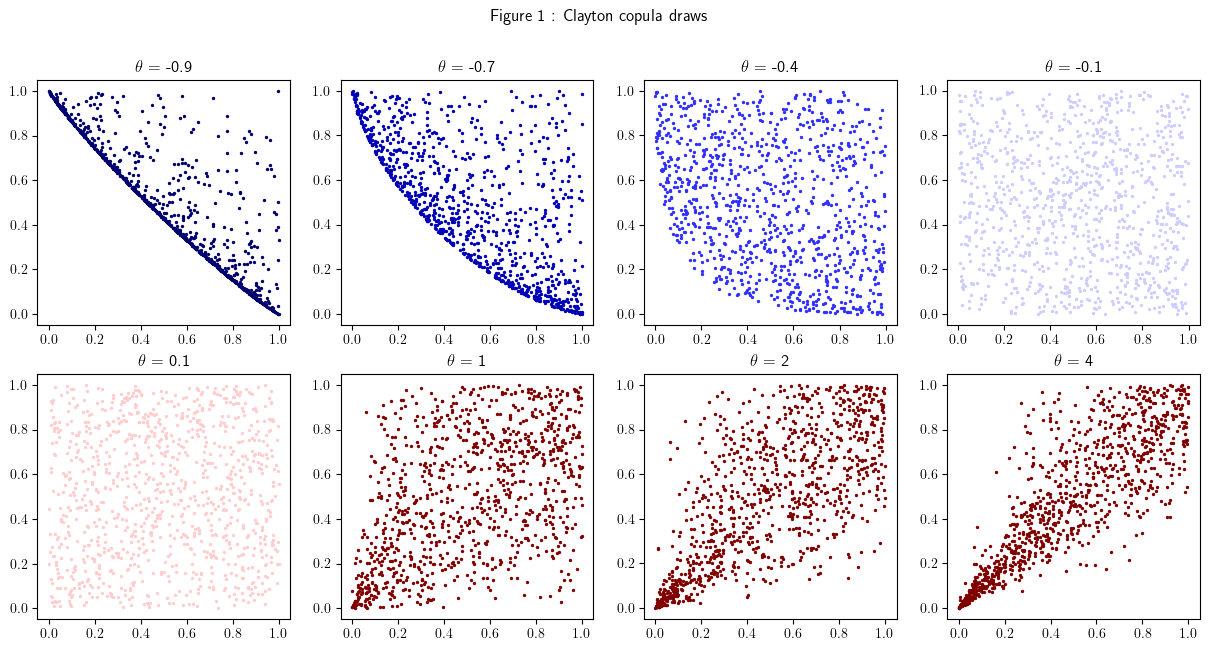

In [ ]:
colormap = mpl.colormaps["seismic"]
legend_line = [] 
linspace_metric = np.linspace(0,3,10)
linspace_dependence_value = [-0.9, -0.7, - 0.4, -0.1, 0.1, 1, 2, 4]

fig, ax = plt.subplot_mosaic([[f"scatter_{line}_{column}" for column in range(4)] for line in range(2)],figsize = (15,7))

for counter,dependence_value in enumerate(linspace_dependence_value):
    cla = Clayton(theta=dependence_value, n_samples=1001)
    sample = cla.sample_unimargin()

    #Create the goal and noise object : 
    goal = GaussianSample(sample[:,0])
    noise = GaussianSample(sample[:,1])

    metric = Metric(goal, noise)

    metric.freeze_sample(goal_arg = {"scale" : 1}, noise_arg = {"scale" : 0.2})
    conditionnal_expectations = []
    for inf_bound in linspace_metric:
        conditionnal_expectations.append(metric.conditionnal_goal(inf_bound))

    ax[f"scatter_{counter//4}_{counter%4}"].scatter(sample[:1000,0],sample[:1000,1],s = 2, color = colormap(dependence_value/2+0.5))
    ax[f"scatter_{counter//4}_{counter%4}"].set_title(f"$\\theta$ = {dependence_value}")
fig.suptitle("Figure 1 : Clayton copula draws")

plt.savefig(r"plot/rebuttal/Figure_1.pdf", format = "pdf")

The scatterplots in the markdown are intended to demonstrates the uniform distribution created by the different copulas, especially showing the kind of dependence structure it create. When points are concentrated $y = 1-x$, the copula is close to the lower limit of negative dependence (called counter-monotonicity), while when points are concentrated along $y = x$ the copula is close to the upper limit of positive dependence possible (called co-monotonicity). For the clayton copula, $\theta <0$ implies a negative dependence while $\theta > 0$ imply a positive dependence.

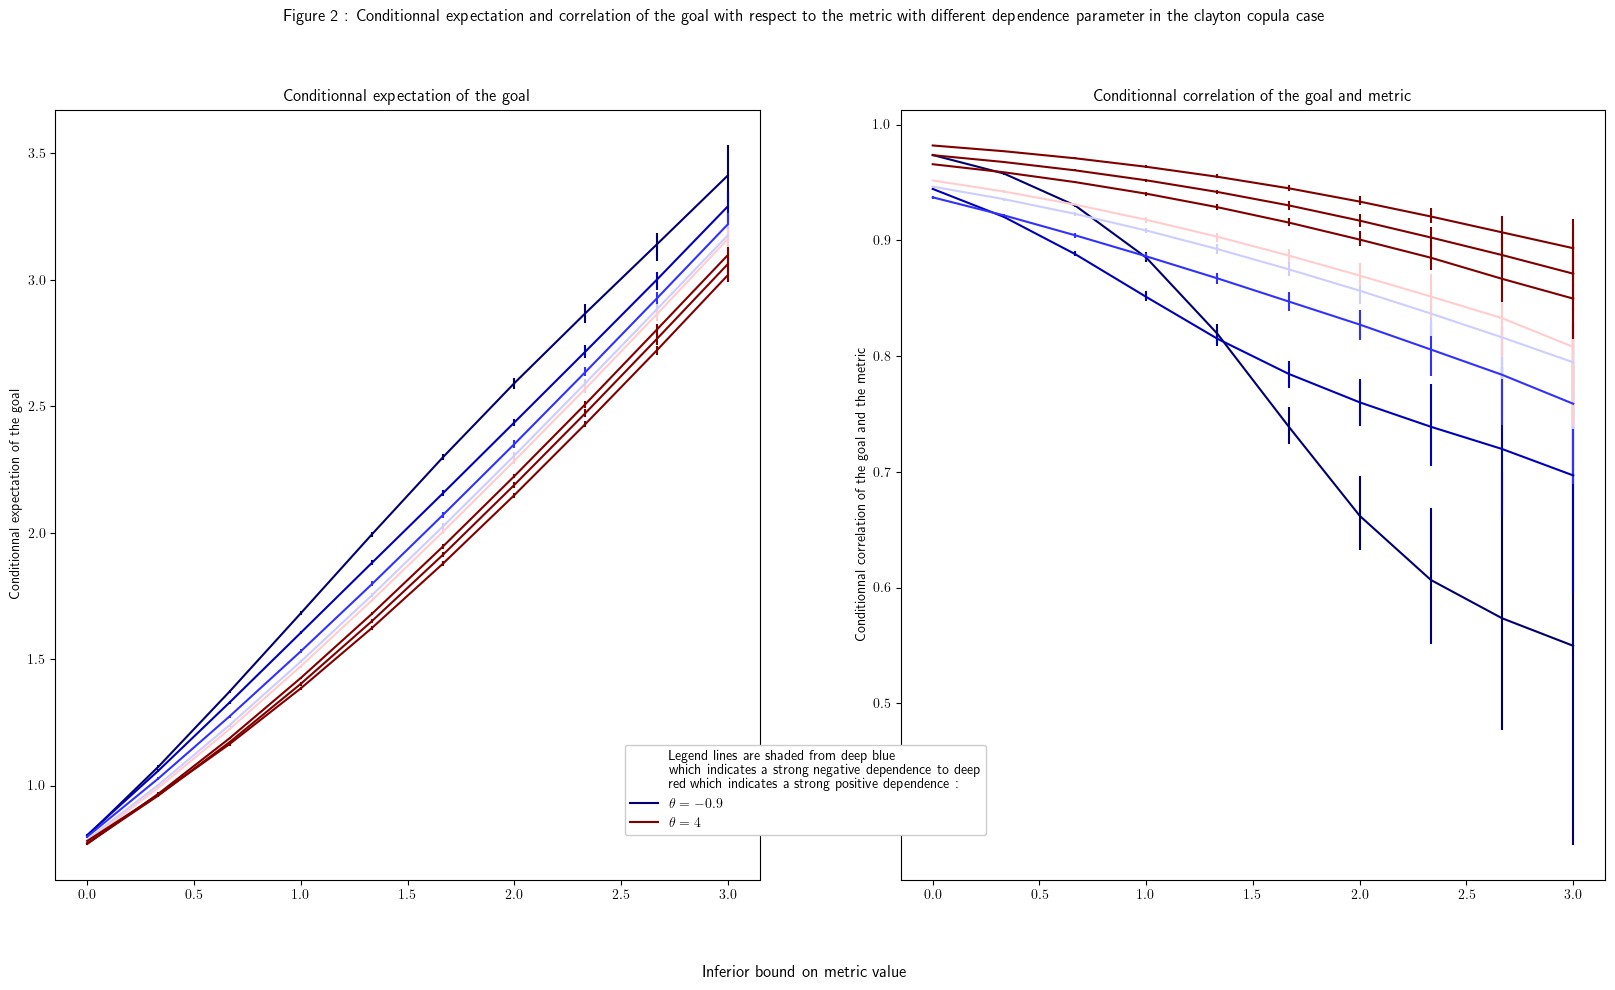

In [ ]:
colormap = mpl.colormaps["seismic"]
legend_line = [] 
linspace_metric = np.linspace(0,3,10)
linspace_dependence_value = [-0.9, -0.7, - 0.4, -0.1, 0.1, 1, 2, 4]
seed_generator = np.random.SeedSequence(1)
seed_sequence = seed_generator.generate_state(100)

fig, ax = plt.subplot_mosaic([["exp","corr"]]
                            ,figsize = (20,10))


for counter,dependence_value in enumerate(linspace_dependence_value):

    mean_exp = np.zeros(len(linspace_metric))
    max_exp = -np.ones((5,len(linspace_metric)))
    min_exp =  10*np.ones((5,len(linspace_metric)))

    mean_corr = np.zeros(len(linspace_metric))
    max_corr = -np.ones((5,len(linspace_metric)))
    min_corr =  10*np.ones((5,len(linspace_metric)))
    
    for counter_seed, seed in enumerate(seed_sequence) :
        np.random.seed(seed)
        cla = Clayton(theta=dependence_value, n_samples=100000)
        sample = cla.sample_unimargin()

        #Create the goal and noise object : 
        goal = GaussianSample(sample[:,0])
        noise = GaussianSample(sample[:,1])

        metric = Metric(goal, noise)

        metric.freeze_sample(goal_arg = {"scale" : 1}, noise_arg = {"scale" : 0.2})
        conditionnal_expectations = []
        conditionnal_correlation = []

        for counter_inf_bound,inf_bound in enumerate(linspace_metric):
            conditionnal_expectations.append(metric.conditionnal_goal(inf_bound))
            conditionnal_correlation.append(metric.conditionnal_correlation(inf_bound)[0,1])

            argmin_exp = np.argmin(max_exp[:,counter_inf_bound])
            argmax_exp = np.argmax(min_exp[:,counter_inf_bound])

            argmin_corr = np.argmin(max_corr[:,counter_inf_bound])
            argmax_corr = np.argmax(min_corr[:,counter_inf_bound])

            if max_exp[argmin_exp,counter_inf_bound] < conditionnal_expectations[-1] :
                max_exp[argmin_exp,counter_inf_bound] = conditionnal_expectations[-1]

            elif min_exp[argmax_exp,counter_inf_bound] > conditionnal_expectations[-1] :
                min_exp[argmax_exp,counter_inf_bound] = conditionnal_expectations[-1]

            if max_corr[argmin_corr,counter_inf_bound] < conditionnal_correlation[-1] :
                max_corr[argmin_corr,counter_inf_bound] = conditionnal_correlation[-1]

            elif min_corr[argmax_corr,counter_inf_bound] > conditionnal_correlation[-1] :
                min_corr[argmax_corr,counter_inf_bound] = conditionnal_correlation[-1]

        mean_exp = (counter_seed/(counter_seed+1))*mean_exp + (1/(counter_seed+1))*np.array(conditionnal_expectations)
        mean_corr = (counter_seed/(counter_seed+1))*mean_corr + (1/(counter_seed+1))*np.array(conditionnal_correlation)

    max_errorbar_exp = np.min(max_exp, axis = 0) - mean_exp
    min_errorbar_exp = mean_exp - np.max(min_exp, axis = 0)

    max_errorbar_corr = np.min(max_corr, axis = 0) - mean_corr
    min_errorbar_corr = mean_corr - np.max(min_corr, axis = 0)

    errorbar_exp = np.array([max_errorbar_exp,min_errorbar_exp])
    errorbar_corr = np.array([max_errorbar_corr,min_errorbar_corr])

    line,_,_ = ax["exp"].errorbar(linspace_metric, mean_exp, yerr = errorbar_exp, color = colormap(dependence_value/2+0.5))
    ax["corr"].errorbar(linspace_metric, mean_corr, yerr = errorbar_corr, color = colormap(dependence_value/2+0.5))

    if dependence_value in [linspace_dependence_value[0], linspace_dependence_value[-1]]: 
        legend_line.append(line)

extra = mpl.patches.Rectangle((0, 0), 1, 1, fc="w", fill=False, edgecolor='none', linewidth=0)

fig.legend([extra] + legend_line,
            ["Legend lines are shaded from deep blue\n which indicates a strong negative dependence to deep\n red which indicates a strong positive dependence : ",f"$\\theta = {linspace_dependence_value[0]}$", f"$\\theta = {linspace_dependence_value[-1]}$"],
            loc='center',
            bbox_to_anchor=(0.5, 0.2),
            framealpha=1)
fig.supxlabel("Inferior bound on metric value")
fig.suptitle("Figure 2 : Conditionnal expectation and correlation of the goal with respect to the metric with different dependence parameter in the clayton copula case")

ax["exp"].set_ylabel("Conditionnal expectation of the goal")
ax["exp"].set_title("Conditionnal expectation of the goal")

ax["corr"].set_ylabel("Conditionnal correlation of the goal and the metric")
ax["corr"].set_title("Conditionnal correlation of the goal and metric")

plt.savefig(r"plot/rebuttal/Figure_2.pdf", format = "pdf")

**Description**: In Figure 1, we look at the conditionnal expectation of the goal depending on the conditionnal inferior bound on the metric in the case of a clayton copula between the goal $G$ and the discrepancy $\xi$. We can see that the conditionnal expectation of the goal grows with the dependence parameter going into the negative : for a dependence parameter of $\theta = -0.9$ (copula close to counter-monotonicity), the conditionnal expectation of the goal is superior by $0.6$ point of the conditionnal expectation of the goal with dependence parameter of $\theta = 4$ (closer to co-monotonicity). The correlation is decreasing to 0, whith a sharper decrease in the cases of negative dependences between the goal and the discrepancy.

**Interpretation**: This hints at the fact that the pattern we devised in the case of gaussian random vector still holds in the case of different copula. Indeed, the Clayton Copula that we use here does is a different copula but still exhibit the same kind of behavior shown in the gaussian vector case. 

### AMH copula : 

In [90]:
from clayton.rng.archimedean import Amh

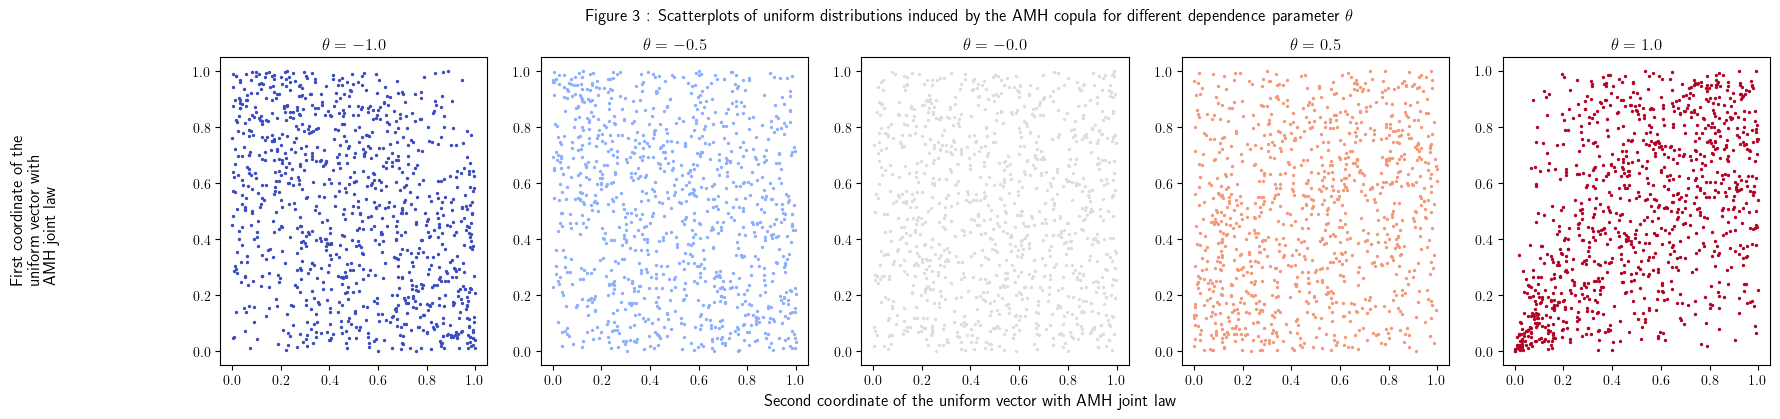

In [93]:
fig, ax = plt.subplot_mosaic([[f"scatter_{column}" for column in range(5)]], figsize = (20,4))

colormap = mpl.colormaps["coolwarm"]
linspace_metric = np.linspace(0,3,10)
linspace_dependence_value = np.linspace(-1,0.999,5)

for counter,dependence_value in enumerate(linspace_dependence_value):
    cla = Amh(theta=dependence_value, n_samples=100000)
    sample = cla.sample_unimargin()

    ax[f"scatter_{counter%5}"].scatter(sample[:1000,0],sample[:1000,1],s = 2, color = colormap(dependence_value/2+0.5))
    ax[f"scatter_{counter%5}"].set_title(f"$\\theta = {np.round(dependence_value,2)}$")

fig.supylabel("First coordinate of the\n uniform vector with\n AMH joint law")
fig.supxlabel("Second coordinate of the uniform vector with AMH joint law", y = 0)
fig.suptitle("Figure 3 : Scatterplots of uniform distributions induced by the AMH copula for different dependence parameter $\\theta$", y = 1)

extra = mpl.patches.Rectangle((0, 0), 1, 1, fc="w", fill=False, edgecolor='none', linewidth=0)

plt.savefig(r"plot/rebuttal/Figure_3.pdf", format = "pdf")

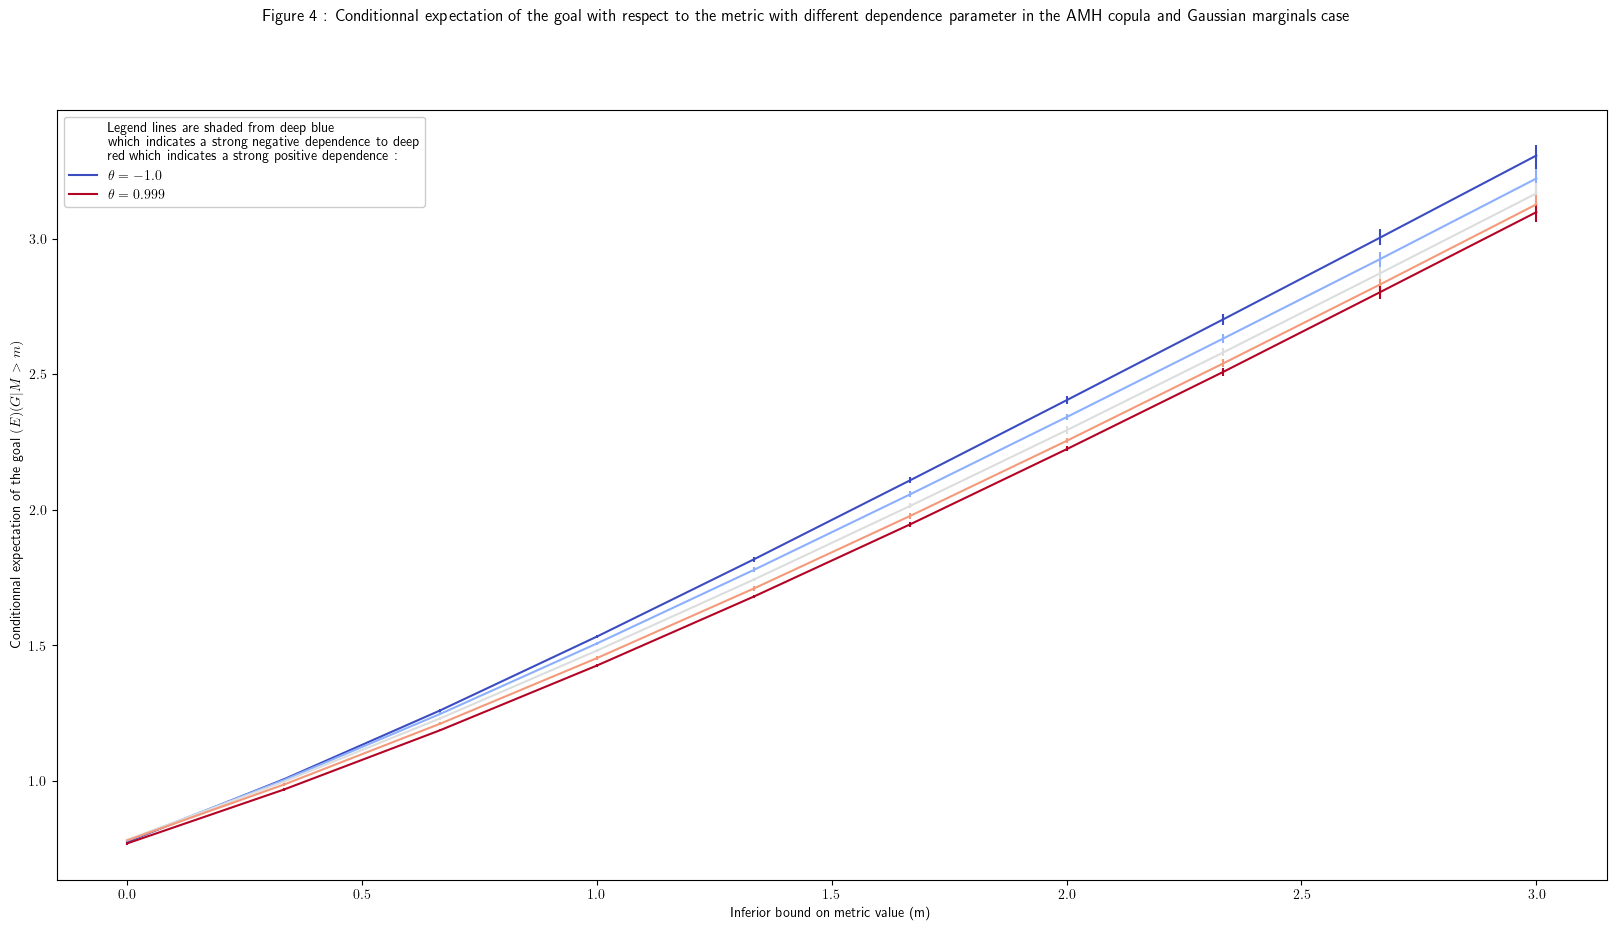

In [ ]:
colormap = mpl.colormaps["coolwarm"]
linspace_metric = np.linspace(0,3,10)
linspace_dependence_value = np.linspace(-1,0.999,5)

legend_line = [] 

seed_generator = np.random.SeedSequence(1)
seed_sequence = seed_generator.generate_state(100)

fig, ax = plt.subplot_mosaic([["exp"]]
                            ,figsize = (20,10))


for counter,dependence_value in enumerate(linspace_dependence_value):

    mean_exp = np.zeros(len(linspace_metric))
    max_exp = -np.ones((5,len(linspace_metric)))
    min_exp =  10*np.ones((5,len(linspace_metric)))

    mean_corr = np.zeros(len(linspace_metric))
    max_corr = -np.ones((5,len(linspace_metric)))
    min_corr =  10*np.ones((5,len(linspace_metric)))
    
    for counter_seed, seed in enumerate(seed_sequence) :
        np.random.seed(seed)
        cla = Amh(theta=dependence_value, n_samples=100000)
        sample = cla.sample_unimargin()

        #Create the goal and noise object : 
        goal = GaussianSample(sample[:,0])
        noise = GaussianSample(sample[:,1])

        metric = Metric(goal, noise)

        metric.freeze_sample(goal_arg = {"scale" : 1}, noise_arg = {"scale" : 0.2})
        conditionnal_expectations = []

        for counter_inf_bound,inf_bound in enumerate(linspace_metric):
            conditionnal_expectations.append(metric.conditionnal_goal(inf_bound))

            argmin_exp = np.argmin(max_exp[:,counter_inf_bound])
            argmax_exp = np.argmax(min_exp[:,counter_inf_bound])

            argmin_corr = np.argmin(max_corr[:,counter_inf_bound])
            argmax_corr = np.argmax(min_corr[:,counter_inf_bound])

            if max_exp[argmin_exp,counter_inf_bound] < conditionnal_expectations[-1] :
                max_exp[argmin_exp,counter_inf_bound] = conditionnal_expectations[-1]

            elif min_exp[argmax_exp,counter_inf_bound] > conditionnal_expectations[-1] :
                min_exp[argmax_exp,counter_inf_bound] = conditionnal_expectations[-1]

        mean_exp = (counter_seed/(counter_seed+1))*mean_exp + (1/(counter_seed+1))*np.array(conditionnal_expectations)

    max_errorbar_exp = np.min(max_exp, axis = 0) - mean_exp
    min_errorbar_exp = mean_exp - np.max(min_exp, axis = 0)

    max_errorbar_corr = np.min(max_corr, axis = 0) - mean_corr
    min_errorbar_corr = mean_corr - np.max(min_corr, axis = 0)

    errorbar_exp = np.array([max_errorbar_exp,min_errorbar_exp])
    errorbar_corr = np.array([max_errorbar_corr,min_errorbar_corr])

    line,_,_ = ax["exp"].errorbar(linspace_metric, mean_exp, yerr = errorbar_exp, color = colormap(dependence_value/2+0.5))

    if dependence_value in [linspace_dependence_value[0], linspace_dependence_value[-1]]: 
        legend_line.append(line)

ax["exp"].set_ylabel("Conditionnal expectation of the goal $\\mathrm(E)(G|M>m)$")
ax["exp"].set_xlabel("Inferior bound on metric value (m)")

extra = mpl.patches.Rectangle((0, 0), 1, 1, fc="w", fill=False, edgecolor='none', linewidth=0)
ax["exp"].legend([extra] + legend_line,
            ["Legend lines are shaded from deep blue\n which indicates a strong negative dependence to deep\n red which indicates a strong positive dependence : ",f"$\\theta = {linspace_dependence_value[0]}$", f"$\\theta = {linspace_dependence_value[-1]}$"],
            loc='upper left',
            framealpha=1)
fig.suptitle("Figure 4 : Conditionnal expectation of the goal with respect to the metric with different dependence parameter in the AMH copula and Gaussian marginals case")

plt.savefig(r"plot/rebuttal/Figure_4.pdf", format = "pdf")

**Description**: In figure 3, we consider the AMH copula with different dependence value. There is a difference of approximately $0.24$ for the conditionnal expectation of the goal $G$ conditionnaly on the metric $M$ being superior or equal to 3.


**Interpretation**: This further hint at the robustness of our findings in the gaussian vector case. 

# Unbalanced tail :

Our goal here is to investigate what could happen in the case of an unbalanced tail setup that would be defavorable (i.e. when the goal has a lighter tail than the noise associated to it). Following our theorem, we know that the noise should be dominant in the metric, however it's unclear what the goal could do in this case. 

### Clayton Copula : 

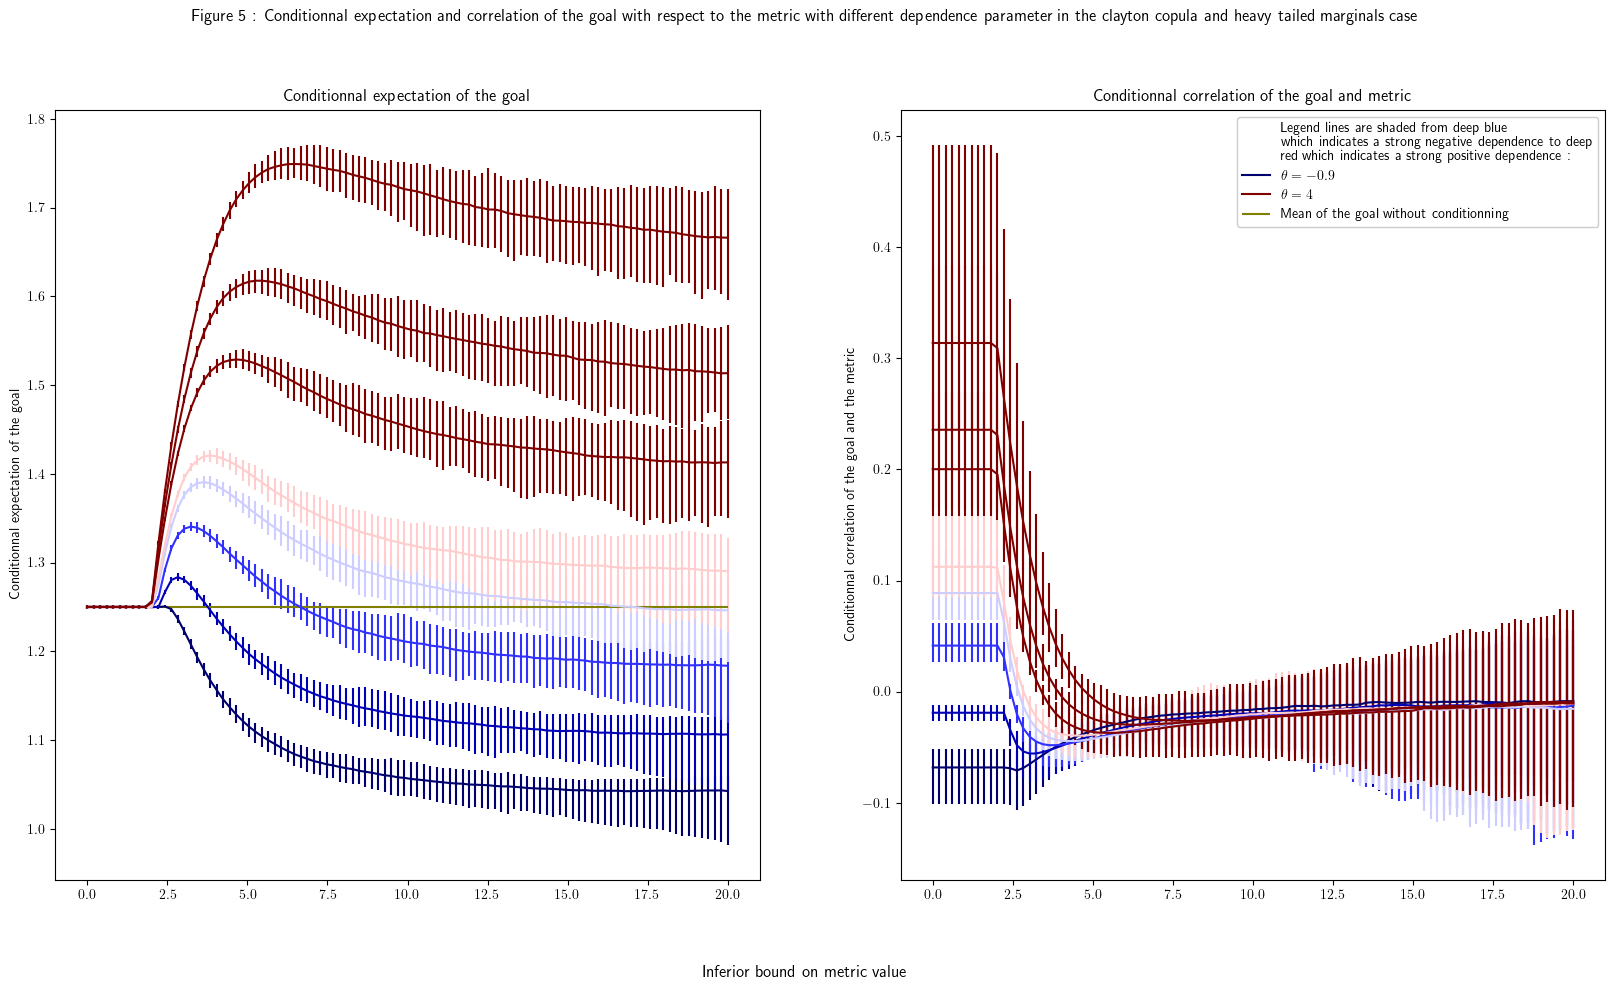

In [73]:
colormap = mpl.colormaps["seismic"]
legend_line = [] 
linspace_metric = np.linspace(0,20,100)
linspace_dependence_value = [-0.9, -0.7, - 0.4, -0.1, 0.1, 1, 2, 4]
seed_generator = np.random.SeedSequence(1)
seed_sequence = seed_generator.generate_state(100)

fig, ax = plt.subplot_mosaic([["exp","corr"]]
                            ,figsize = (20,10))


for counter,dependence_value in enumerate(linspace_dependence_value):
    file_exp = Path(f"data/clayton_copula_5_2/exp_{counter}.pc")
    file_errorbar = Path(f"data/clayton_copula_5_2/errorbar_{counter}.pc")
    if not file_exp.is_file():
        mean_exp = np.zeros(len(linspace_metric))
        max_exp = -np.ones((5,len(linspace_metric)))
        min_exp =  10*np.ones((5,len(linspace_metric)))

        mean_corr = np.zeros(len(linspace_metric))
        max_corr = -np.ones((5,len(linspace_metric)))
        min_corr =  10*np.ones((5,len(linspace_metric)))

        for counter_seed, seed in enumerate(seed_sequence) :
            np.random.seed(seed)
            cla = Clayton(theta=dependence_value, n_samples=100000)
            sample = cla.sample_unimargin()

            #Create the goal and noise object : 
            goal = HeavyTailSample(sample[:,0])
            noise = HeavyTailSample(sample[:,1])

            metric = Metric(goal, noise)

            metric.freeze_sample(goal_arg = {"cutoff" : 1, "tail_parameter" : 1/5}, noise_arg = {"cutoff" : 1, "tail_parameter" : 1/2})
            conditionnal_expectations = []
            conditionnal_correlation = []

            for counter_inf_bound,inf_bound in enumerate(linspace_metric):
                conditionnal_expectations.append(metric.conditionnal_goal(inf_bound))
                conditionnal_correlation.append(metric.conditionnal_correlation(inf_bound)[0,1])

                argmin_exp = np.argmin(max_exp[:,counter_inf_bound])
                argmax_exp = np.argmax(min_exp[:,counter_inf_bound])

                argmin_corr = np.argmin(max_corr[:,counter_inf_bound])
                argmax_corr = np.argmax(min_corr[:,counter_inf_bound])

                if max_exp[argmin_exp,counter_inf_bound] < conditionnal_expectations[-1] :
                    max_exp[argmin_exp,counter_inf_bound] = conditionnal_expectations[-1]

                elif min_exp[argmax_exp,counter_inf_bound] > conditionnal_expectations[-1] :
                    min_exp[argmax_exp,counter_inf_bound] = conditionnal_expectations[-1]

                if max_corr[argmin_corr,counter_inf_bound] < conditionnal_correlation[-1] :
                    max_corr[argmin_corr,counter_inf_bound] = conditionnal_correlation[-1]

                elif min_corr[argmax_corr,counter_inf_bound] > conditionnal_correlation[-1] :
                    min_corr[argmax_corr,counter_inf_bound] = conditionnal_correlation[-1]

            mean_exp = (counter_seed/(counter_seed+1))*mean_exp + (1/(counter_seed+1))*np.array(conditionnal_expectations)
            mean_corr = (counter_seed/(counter_seed+1))*mean_corr + (1/(counter_seed+1))*np.array(conditionnal_correlation)

        max_errorbar_exp = np.min(max_exp, axis = 0) - mean_exp
        min_errorbar_exp = mean_exp - np.max(min_exp, axis = 0)

        max_errorbar_corr = np.min(max_corr, axis = 0) - mean_corr
        min_errorbar_corr = mean_corr - np.max(min_corr, axis = 0)

        errorbar_exp = np.array([max_errorbar_exp,min_errorbar_exp])
        errorbar_corr = np.array([max_errorbar_corr,min_errorbar_corr])
        with open(file_errorbar, "wb") as file :
            pc.dump(errorbar_exp,file)
            pc.dump(errorbar_corr,file)
        with open(file_exp, "wb") as file:
            pc.dump(mean_exp, file)
            pc.dump(mean_corr, file)
    else : 
        with open(file_errorbar, "rb") as file :
            errorbar_exp = pc.load(file)
            errorbar_corr = pc.load(file)
        with open(file_exp, "rb") as file:
            mean_exp = pc.load(file)
            mean_corr = pc.load(file)

    line,_,_ = ax["exp"].errorbar(linspace_metric, mean_exp, yerr = errorbar_exp, color = colormap(dependence_value/2+0.5))
    ax["corr"].errorbar(linspace_metric, mean_corr, yerr = errorbar_corr, color = colormap(dependence_value/2+0.5))

    if dependence_value in [linspace_dependence_value[0], linspace_dependence_value[-1]]: 
        legend_line.append(line)
    
line = ax["exp"].hlines(5/4,0,20, colors="olive")
legend_line.append(line)

extra = mpl.patches.Rectangle((0, 0), 1, 1, fc="w", fill=False, edgecolor='none', linewidth=0)

ax["corr"].legend([extra] + legend_line,
            ["Legend lines are shaded from deep blue\n which indicates a strong negative dependence to deep\n red which indicates a strong positive dependence : ",
            f"$\\theta = {linspace_dependence_value[0]}$",
            f"$\\theta = {linspace_dependence_value[-1]}$",
            "Mean of the goal without conditionning"],
            loc='upper right',
            #bbox_to_anchor=(0.5, 0.2),
            framealpha=1)
fig.supxlabel("Inferior bound on metric value")
fig.suptitle("Figure 5 : Conditionnal expectation and correlation of the goal with respect to the metric with different dependence parameter in the clayton copula and heavy tailed marginals case")

ax["exp"].set_ylabel("Conditionnal expectation of the goal")
ax["exp"].set_title("Conditionnal expectation of the goal")

ax["corr"].set_ylabel("Conditionnal correlation of the goal and the metric")
ax["corr"].set_title("Conditionnal correlation of the goal and metric")

plt.savefig(r"plot/rebuttal/Figure_5.pdf", format = "pdf")

**Description**: In Figure 5, we see the evolution of the empirical expected value of the goal with a growing threshold on the metric. The goal in the case of a positive dependence ($\theta > 0$) first grows to then stabilize up to $0.7$ point higher than the mean of the goal. However, in the negative dependence case ($\theta < 0$) the conditionnal expected value of the goal decrease to the proximity of its minimum value (near $1$)

**Interpretation**: This result hint toward 2 things : 

1 - Even when the dependence structure is favorable to the goal (in the sens that it is positively correlated to the goal), it seems that its mean value is stabilizing higher than the expected value, showing that the optimization is useful up to a certain point (advocating for an early stopping procedure : selecting instance where the metric is above 20 seems to bring almost no benefit to the goal). 


2 - In the case of an unfavorable dependence structure, the optimization seems at least counter productive : the expected value of the goal after optimization is lower or equal to the expected value without the goal. 

### Gaussian Copula : 

In [66]:
from clayton.rng import Gaussian


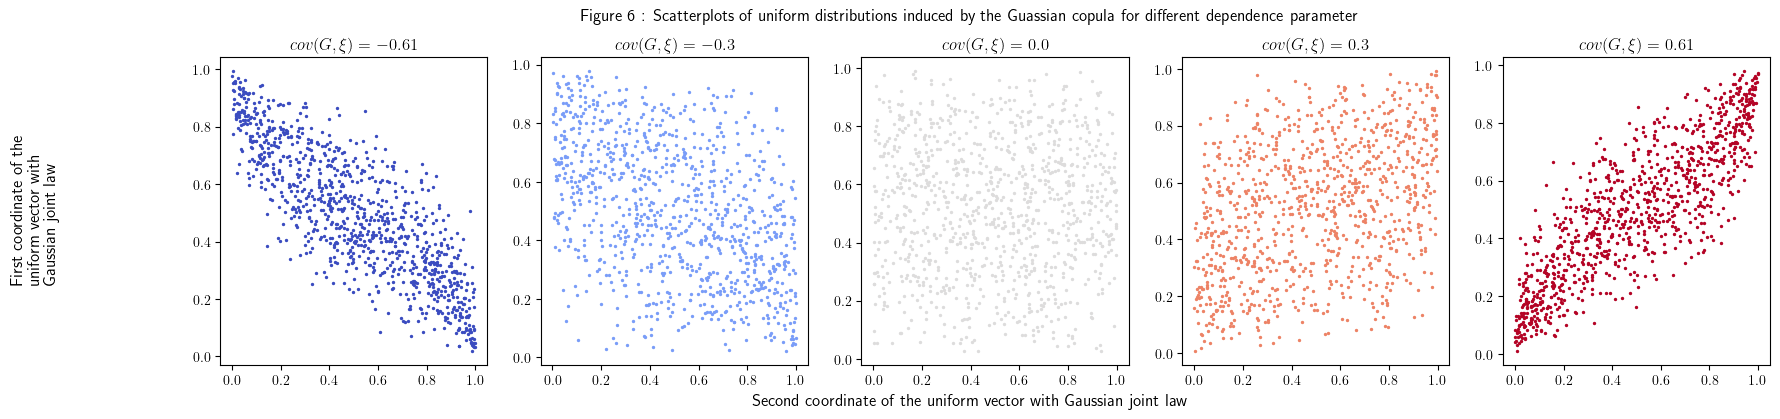

In [92]:
colormap = mpl.colormaps["coolwarm"]
legend_line = [] 
noise_variance = 1/2
linspace_dependence_value = np.linspace(-np.sqrt(noise_variance)+0.1, np.sqrt(noise_variance)-0.1,5)

fig, ax = plt.subplot_mosaic([[f"scatter_{column}" for column in range(5)]], figsize = (20,4))

for counter,dependence_value in enumerate(linspace_dependence_value):
    cla = Gaussian(n_samples=1001)

    cla.d = 2
    cla.sigmat = np.array([[1,dependence_value],[dependence_value,1/2]])

    sample = cla.sample_unimargin()

    ax[f"scatter_{counter}"].scatter(sample[:1000,0],sample[:1000,1],s = 2, color = colormap(dependence_value+1/2))
    ax[f"scatter_{counter}"].set_title(f"$cov(G,\\xi) = {np.round(dependence_value,2)}$")
fig.supylabel("First coordinate of the\n uniform vector with\n Gaussian joint law")
fig.supxlabel("Second coordinate of the uniform vector with Gaussian joint law", y = 0)
fig.suptitle("Figure 6 : Scatterplots of uniform distributions induced by the Guassian copula for different dependence parameter", y = 1)

extra = mpl.patches.Rectangle((0, 0), 1, 1, fc="w", fill=False, edgecolor='none', linewidth=0)

plt.savefig(r"plot/rebuttal/Figure_6.pdf", format = "pdf")

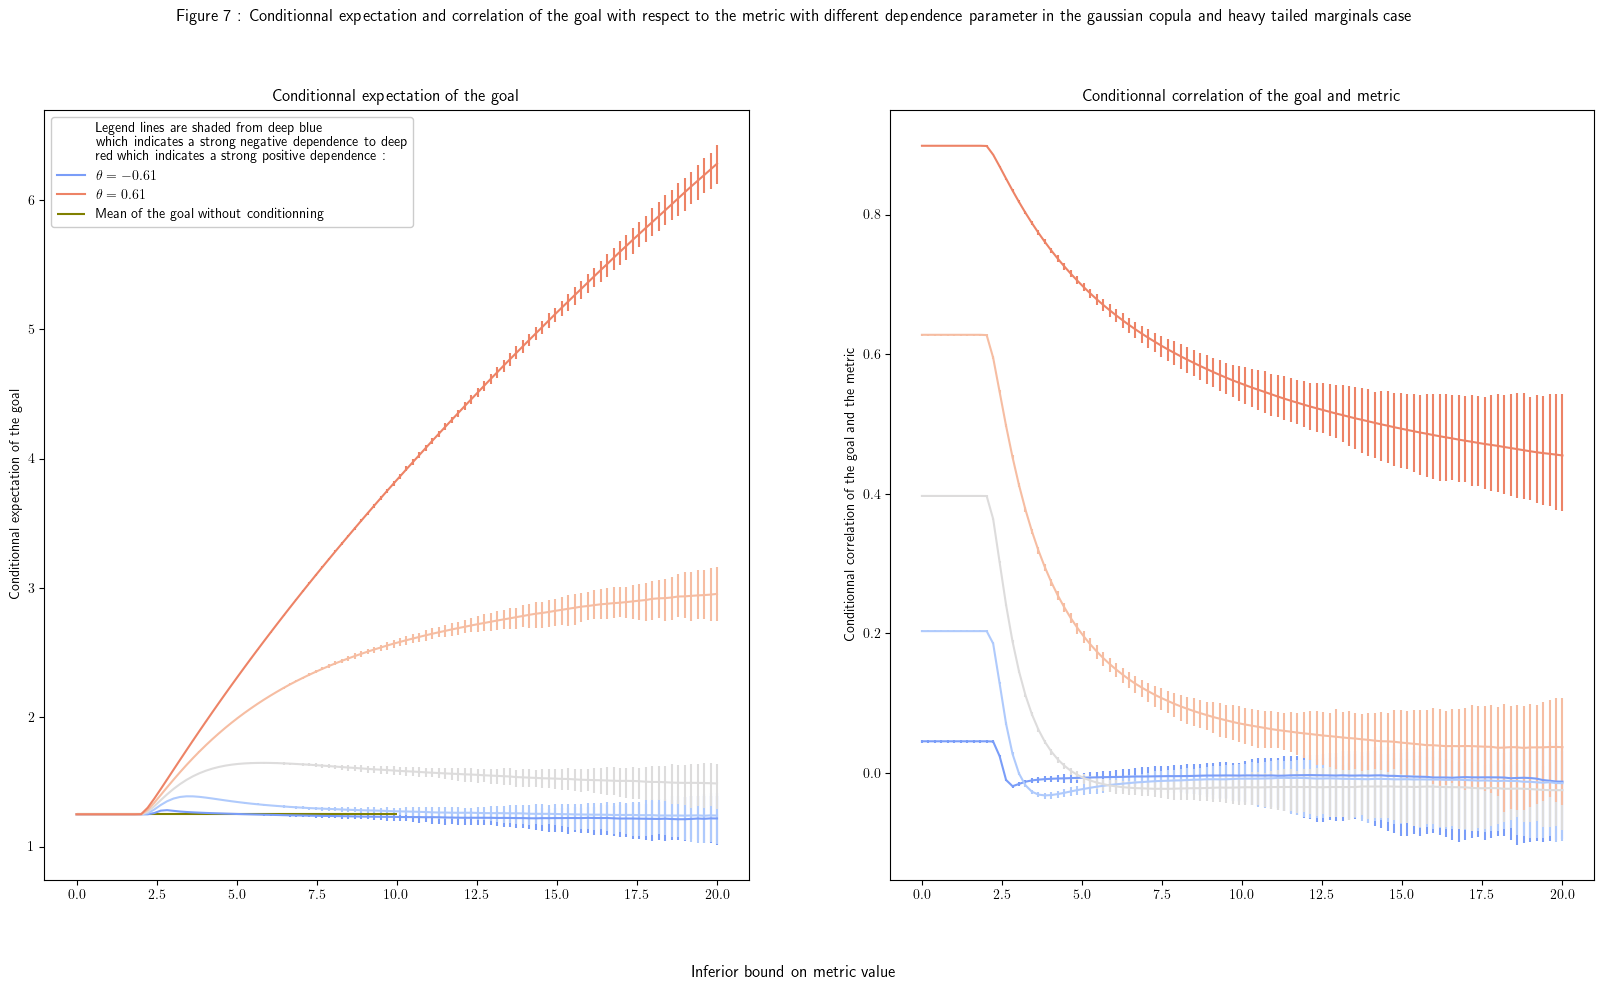

In [88]:
colormap = mpl.colormaps["coolwarm"]
legend_line = [] 
linspace_metric = np.linspace(0,20,100)

noise_variance = 1/2
linspace_dependence_value = np.linspace(-np.sqrt(noise_variance)+0.1, np.sqrt(noise_variance)-0.1,5)

seed_generator = np.random.SeedSequence(1)
seed_sequence = seed_generator.generate_state(100)

fig, ax = plt.subplot_mosaic([["exp","corr"]]
                            ,figsize = (20,10))

for counter,dependence_value in enumerate(linspace_dependence_value):
    file_exp = Path(f"data/gaussian_copula_5_2/exp_{counter}.pc")
    file_errorbar = Path(f"data/gaussian_copula_5_2/errorbar_{counter}.pc")
    if not file_exp.is_file():
        mean_exp = np.zeros(len(linspace_metric))
        max_exp = -np.ones((5,len(linspace_metric)))
        min_exp =  10*np.ones((5,len(linspace_metric)))

        mean_corr = np.zeros(len(linspace_metric))
        max_corr = -np.ones((5,len(linspace_metric)))
        min_corr =  10*np.ones((5,len(linspace_metric)))

        for counter_seed, seed in enumerate(seed_sequence) :
            np.random.seed(seed)
            cla = Gaussian(n_samples=10000000)

            cla.d = 2
            cla.sigmat = np.array([[1,dependence_value],[dependence_value,1/2]])

            sample = cla.sample_unimargin()

            #Create the goal and noise object : 
            goal = HeavyTailSample(sample[:,0])
            noise = HeavyTailSample(sample[:,1])

            metric = Metric(goal, noise)

            metric.freeze_sample(goal_arg = {"cutoff" : 1, "tail_parameter" : 1/5}, noise_arg = {"cutoff" : 1, "tail_parameter" : 1/2})
            conditionnal_expectations = []
            conditionnal_correlation = []

            for counter_inf_bound,inf_bound in enumerate(linspace_metric):
                conditionnal_expectations.append(metric.conditionnal_goal(inf_bound))
                conditionnal_correlation.append(metric.conditionnal_correlation(inf_bound)[0,1])

                argmin_exp = np.argmin(max_exp[:,counter_inf_bound])
                argmax_exp = np.argmax(min_exp[:,counter_inf_bound])

                argmin_corr = np.argmin(max_corr[:,counter_inf_bound])
                argmax_corr = np.argmax(min_corr[:,counter_inf_bound])

                if max_exp[argmin_exp,counter_inf_bound] < conditionnal_expectations[-1] :
                    max_exp[argmin_exp,counter_inf_bound] = conditionnal_expectations[-1]

                elif min_exp[argmax_exp,counter_inf_bound] > conditionnal_expectations[-1] :
                    min_exp[argmax_exp,counter_inf_bound] = conditionnal_expectations[-1]

                if max_corr[argmin_corr,counter_inf_bound] < conditionnal_correlation[-1] :
                    max_corr[argmin_corr,counter_inf_bound] = conditionnal_correlation[-1]

                elif min_corr[argmax_corr,counter_inf_bound] > conditionnal_correlation[-1] :
                    min_corr[argmax_corr,counter_inf_bound] = conditionnal_correlation[-1]

            mean_exp = (counter_seed/(counter_seed+1))*mean_exp + (1/(counter_seed+1))*np.array(conditionnal_expectations)
            mean_corr = (counter_seed/(counter_seed+1))*mean_corr + (1/(counter_seed+1))*np.array(conditionnal_correlation)

        max_errorbar_exp = np.min(max_exp, axis = 0) - mean_exp
        min_errorbar_exp = mean_exp - np.max(min_exp, axis = 0)

        max_errorbar_corr = np.abs(np.min(max_corr, axis = 0) - mean_corr)
        min_errorbar_corr = np.abs(mean_corr - np.max(min_corr, axis = 0))

        errorbar_exp = np.array([max_errorbar_exp,min_errorbar_exp])
        errorbar_corr = np.array([max_errorbar_corr,min_errorbar_corr])

        with open(file_errorbar, "wb") as file :
            pc.dump(errorbar_exp,file)
            pc.dump(errorbar_corr,file)
        with open(file_exp, "wb") as file:
            pc.dump(mean_exp, file)
            pc.dump(mean_corr, file)
    else : 
        with open(file_errorbar, "rb") as file :
            errorbar_exp = pc.load(file)
            errorbar_corr = pc.load(file)
        with open(file_exp, "rb") as file:
            mean_exp = pc.load(file)
            mean_corr = pc.load(file)
    line,_,_ = ax["exp"].errorbar(linspace_metric, mean_exp, yerr = errorbar_exp, color = colormap(dependence_value/2+0.5))
    ax["corr"].errorbar(linspace_metric, mean_corr, yerr = errorbar_corr, color = colormap(dependence_value/2+0.5))

    if dependence_value in [linspace_dependence_value[0], linspace_dependence_value[-1]]: 
        legend_line.append(line)


line = ax["exp"].hlines(5/4,0,10, colors="olive")
legend_line.append(line)

extra = mpl.patches.Rectangle((0, 0), 1, 1, fc="w", fill=False, edgecolor='none', linewidth=0)

ax["exp"].legend([extra] + legend_line,
            ["Legend lines are shaded from deep blue\n which indicates a strong negative dependence to deep\n red which indicates a strong positive dependence : ",
            f"$\\theta = {np.round(linspace_dependence_value[0],2)}$",
            f"$\\theta = {np.round(linspace_dependence_value[-1],2)}$",
            "Mean of the goal without conditionning"],
            loc='upper left',
            #bbox_to_anchor=(0.5, 0.2),
            framealpha=1)
fig.supxlabel("Inferior bound on metric value")
fig.suptitle("Figure 7 : Conditionnal expectation and correlation of the goal with respect to the metric with different dependence parameter in the gaussian copula and heavy tailed marginals case")

ax["exp"].set_ylabel("Conditionnal expectation of the goal")
ax["exp"].set_title("Conditionnal expectation of the goal")

ax["corr"].set_ylabel("Conditionnal correlation of the goal and the metric")
ax["corr"].set_title("Conditionnal correlation of the goal and metric")

plt.savefig(r"plot/rebuttal/Figure_7.pdf", format = "pdf")

**Description**: In Figure 7, we see the evolution of the empirical expected value of the goal with a growing threshold on the metric in the case of the gaussian copula. The goal in the case of a positive dependence ($cov(\xi,G) > 0$) first grows to then seems to stabilize except for the almost degenerated case $cov(\xi,G) \eqsim \sqrt{Var(\xi)}$. In the negative dependence case ($cov(\xi,G) < 0$) the conditionnal expected value of the goal grows first to then decrease near the expected value of $G$ without optimization.

**Interpretation**: This results further point 2 precedently stated. Point 1 is not as clear as in the favorable cases where the copula, the goal seems to grow with optimization, although much more slowly than the metric.